# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

Faça a leitura dos dados do arquivo CSV:


Altere o código abaixo de acordo com seu diretório.

In [20]:
df = pd.read_csv("MODULO7_PROJETOFINAL_BASE_SUPERMERCADO - MODULO7_PROJETOFINAL_BASE_SUPERMERCADO.csv", delimiter=',')



df.head(10)

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
5,"Pack 12 un, Leche sin lactosa frutilla 1 L",Loncoleche,17988,0,0,0,lacteos
6,"Pack 12 un, Leche saborizada light chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
7,"Pack 12 un, Leche saborizada frutilla 1 L",Colun,17388,0,0,0,lacteos
8,"Pack 12 un, Leche saborizada vainilla 1 L",Colun,17388,0,0,0,lacteos
9,"Pack 12 un, Leche saborizada manjar 1 L",Colun,17388,0,0,0,lacteos


Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [21]:
print(df.columns)


Index(['title', 'Marca', 'Preco_Normal', 'Preco_Desconto', 'Preco_Anterior',
       'Desconto', 'Categoria'],
      dtype='object')


In [23]:
#Seu código aqui para a média
#df['Preco_Normal'].mean()
df.groupby('Categoria')['Preco_Normal'].mean().reset_index().sort_values(by='Preco_Normal', ascending=False)

,Categoria,Preco_Normal
1,comidas-preparadas,3095.043478
5,lacteos,2385.219239
2,congelados,2108.042553
0,belleza-y-cuidado-personal,1783.556485
3,frutas,1724.473684
6,verduras,1343.296875
4,instantaneos-y-sopas,765.491228


In [24]:
#Seu código aqui para a mediana
df.groupby('Categoria')['Preco_Normal'].median().reset_index().sort_values(by='Preco_Normal', ascending=False)

,Categoria,Preco_Normal
1,comidas-preparadas,3290.0
0,belleza-y-cuidado-personal,1569.0
2,congelados,1519.0
3,frutas,1195.0
6,verduras,1180.0
5,lacteos,989.0
4,instantaneos-y-sopas,439.0


Digite aqui as categorias:


*   comidas-preparadas: A média (3095.04) é ligeiramente inferior à mediana (3290.0), indicando que alguns preços podem ser mais altos, puxando a mediana para cima.
*   lacteos: A média (2385.22) é significativamente superior à mediana (989.0), sugerindo que alguns preços são consideravelmente mais altos que a maioria, afetando a média.


*  congelados: A média (2108.04) é superior à mediana (1519.0), indicando novamente que alguns preços mais altos influenciam a média.
*   belleza-y-cuidado-personal: A média (1783.56) é ligeiramente superior à mediana (1569.0), com um comportamento semelhante a "congelados", mas com menor diferença.

*   frutas: A média (1724.47) é superior à mediana (1195.0), indicando que alguns preços mais altos afetam a média.
*   verduras: A média (1343.30) é ligeiramente superior à mediana (1180.0), com um padrão similar aos casos anteriores, mas com menor diferença.

*   instantaneos-y-sopas: A média (765.49) é superior à mediana (439.0), mostrando que alguns preços mais altos influenciam a média.










# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio?

In [26]:
desvio_padrao_por_categoria = df.groupby('Categoria')['Preco_Normal'].std().reset_index()
desvio_padrao_por_categoria


,Categoria,Preco_Normal
0,belleza-y-cuidado-personal,2210.041719
1,comidas-preparadas,2019.911428
2,congelados,2111.539896
3,frutas,1639.151114
4,instantaneos-y-sopas,1170.232869
5,lacteos,3925.816164
6,verduras,1012.699625


Digite nesse campo o comportamento que você identificou.


*   lacteos: A média (2385.22) é muito superior à mediana (989.0), indicando que a distribuição dos preços de produtos lácteos é assimétrica positiva (ou seja, com valores atípicos altos). Isso significa que alguns produtos lácteos têm preços muito acima da média, "puxando" a média para cima e distorcendo a representação do preço típico da categoria.
*   belleza-y-cuidado-personal: A média (1783.56) é ligeiramente superior à mediana (1569.0), sugerindo uma assimetria positiva menos intensa que em "lacteos". Ainda há alguns preços mais altos que influenciam a média, mas a diferença não é tão grande.

*   congelados: A média (2108.04) é superior à mediana (1519.0), indicando novamente uma assimetria positiva. A diferença é considerável, mostrando que alguns produtos congelados têm preços mais altos que a maioria, afetando a média.





# 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

Dica: Para trazer apenas os dados da categoria que você deseja você pode usar o df.loc[df['Categoria'] == 'CATEGORIA ESCOLHIDA'

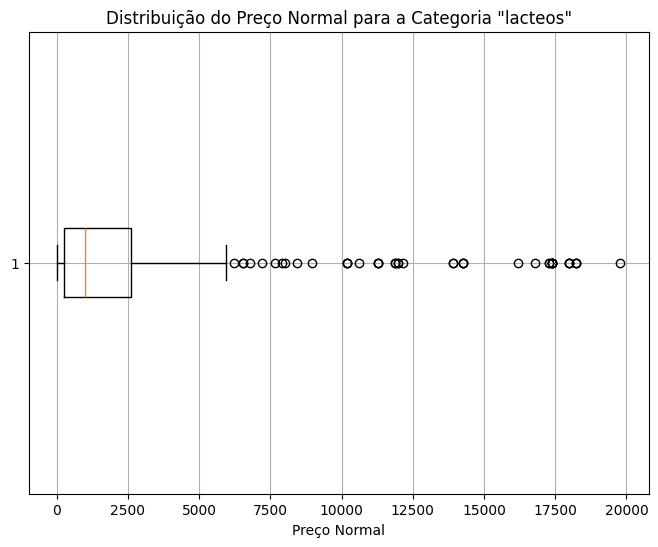

In [28]:
lacteos = df.loc[df['Categoria'] == 'lacteos']

plt.figure(figsize=(8, 6))
plt.boxplot(lacteos['Preco_Normal'], vert=False)
plt.xlabel('Preço Normal')
plt.title('Distribuição do Preço Normal para a Categoria "lacteos"')
plt.grid(True)
plt.show()


Com base na análise do boxplot, podemos descrever a distribuição dos dados da categoria "lacteos" e identificar a presença de outliers

# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

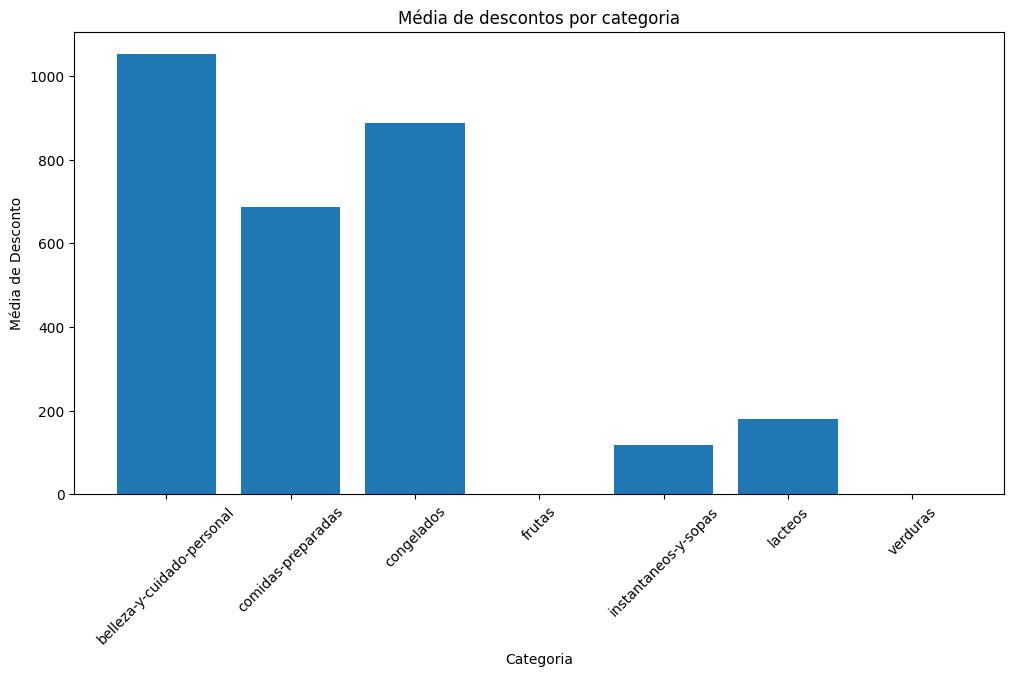

In [33]:
media_desconto = df.groupby('Categoria')['Preco_Desconto'].mean()

plt.figure(figsize=(12,6))
plt.bar(media_desconto.index, media_desconto.values)
plt.title('Média de descontos por categoria')
plt.xlabel('Categoria')
plt.ylabel('Média de Desconto')
plt.xticks(rotation=45)
plt.show()


# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

In [43]:
df['Desconto'] = df['Desconto'].replace(0, 0.01)
df = df[df['Desconto'] != 0]

In [44]:
media_desconto_por_categoria_marca = df.groupby(['Categoria', 'Marca'])['Desconto'].mean().reset_index()
fig = px.treemap(media_desconto_por_categoria_marca,
                 path=['Categoria', 'Marca'],
                 values='Desconto',
                 title='Média de Desconto por Categoria e Marca',
                 color='Desconto',
                 color_continuous_scale='Blues')
fig.show()